In [22]:
import pandas as pd
import numpy as np

from scipy.stats import norm
import matplotlib.pyplot as plt


In [23]:
data=pd.read_csv("AsianPaints_Model_Data_2023_25.csv")

In [24]:
df=data.copy()
df

,Date,S,K,T,r,sigma,Market_Price,vix,vol_ma
0,2023-01-31,2876.6,2820.0,0.156164,0.067,0.000000,103.15,16.879999,1370927.8
1,2023-01-31,2876.6,3240.0,0.156164,0.067,0.000000,14.85,16.879999,1370927.8
2,2023-01-31,2876.6,3460.0,0.156164,0.067,0.000000,4.25,16.879999,1370927.8
3,2023-01-31,2876.6,3040.0,0.156164,0.067,0.000000,40.50,16.879999,1370927.8
4,2023-01-31,2876.6,2620.0,0.156164,0.067,0.000000,206.00,16.879999,1370927.8
...,...,...,...,...,...,...,...,...,...
77179,2025-12-31,2769.5,2600.0,0.243836,0.067,0.200426,240.60,9.480000,1593596.6
77180,2025-12-31,2769.5,2640.0,0.243836,0.067,0.200426,211.75,9.480000,1593596.6
77181,2025-12-31,2769.5,2800.0,0.243836,0.067,0.200426,117.10,9.480000,1593596.6
77182,2025-12-31,2769.5,2960.0,0.243836,0.067,0.200426,56.55,9.480000,1593596.6


In [25]:
def bs_call(S, K, T, r, sigma, q=0.01):
    if T <= 0 or sigma <= 0:
        return np.nan
    
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    
    return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def vega(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)


def implied_vol(S, K, T, r, market_price, tol=1e-5, max_iter=100):
    sigma = 0.2  # initial guess
    
    for _ in range(max_iter):
        price = bs_call(S, K, T, r, sigma)
        v = vega(S, K, T, r, sigma)
        
        if v < 1e-8:
            return np.nan
        
        diff = price - market_price
        
        if abs(diff) < tol:
            return sigma
        
        sigma -= diff / v
        
        if sigma <= 0:
            sigma = 1e-4
    
    return np.nan


# df['sigma_iv'] = df.apply(
#     lambda row: implied_vol(
#         row['S'],
#         row['K'],
#         row['T'],
#         row['r'],
#         row['Market_Price']
#     ),
#     axis=1
# )

In [26]:
# Apply BS
df["bs_price"] = df.apply(
    lambda row: bs_call(
        row["S"], row["K"], row["T"],
        row["r"], row["sigma"]
    ), axis=1
)

# Error
df["error"] = df["Market_Price"] - df["bs_price"]

In [27]:
df = df.replace([np.inf, -np.inf], np.nan).dropna()

In [28]:
# Core transforms
df["log_moneyness"] = np.log(df["S"] / df["K"])
df["sqrt_T"] = np.sqrt(df["T"])
df["sigma_sqrt_T"] = df["sigma"] * df["sqrt_T"]

# Clean
df = df.replace([np.inf, -np.inf], np.nan).dropna()

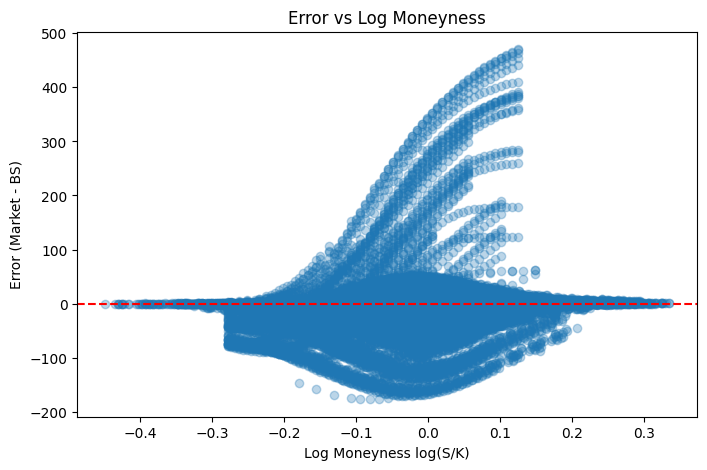

In [29]:
plt.figure(figsize=(8,5))

plt.scatter(df["log_moneyness"], df["error"], alpha=0.3)

plt.xlabel("Log Moneyness log(S/K)")
plt.ylabel("Error (Market - BS)")
plt.title("Error vs Log Moneyness")
plt.axhline(0, color='red', linestyle='--')
plt.show()

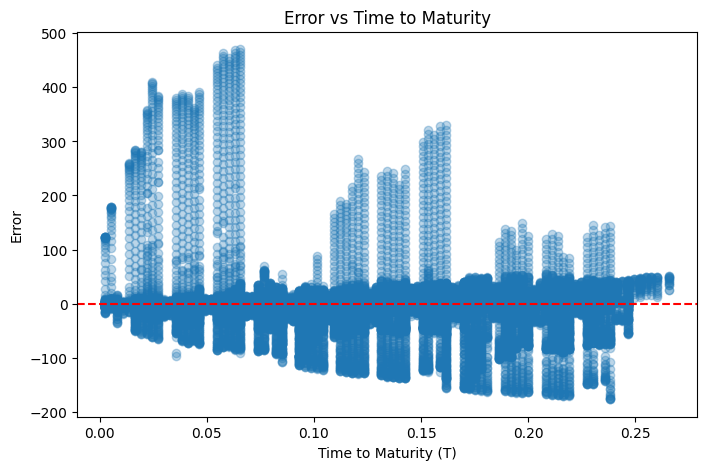

In [30]:
plt.figure(figsize=(8,5))

plt.scatter(df["T"], df["error"], alpha=0.3)

plt.xlabel("Time to Maturity (T)")
plt.ylabel("Error")
plt.title("Error vs Time to Maturity")
plt.axhline(0, color='red', linestyle='--')
plt.show()

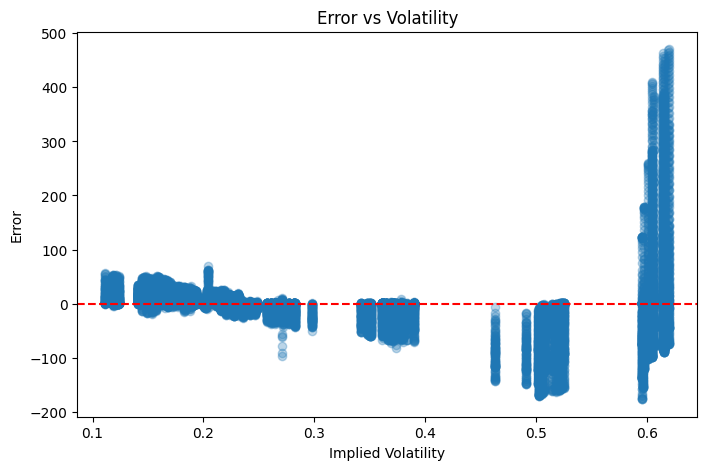

In [31]:
plt.figure(figsize=(8,5))

plt.scatter(df["sigma"], df["error"], alpha=0.3)

plt.xlabel("Implied Volatility")
plt.ylabel("Error")
plt.title("Error vs Volatility")
plt.axhline(0, color='red', linestyle='--')

plt.show()

In [32]:
df.head()

,Date,S,K,T,r,sigma,Market_Price,vix,vol_ma,bs_price,error,log_moneyness,sqrt_T,sigma_sqrt_T
17011,2024-01-01,2876.6,3340.0,0.161644,0.067,0.619995,158.60,10.8,623249.8,137.089149,21.510851,-0.149362,0.40205,0.249269
17012,2024-01-01,2876.6,3760.0,0.161644,0.067,0.619995,17.75,10.8,623249.8,62.862587,-45.112587,-0.267810,0.40205,0.249269
17013,2024-01-01,2876.6,3420.0,0.161644,0.067,0.619995,114.10,10.8,623249.8,118.776958,-4.676958,-0.173032,0.40205,0.249269
17014,2024-01-01,2876.6,3120.0,0.161644,0.067,0.619995,324.20,10.8,623249.8,200.451555,123.748445,-0.081224,0.40205,0.249269
17015,2024-01-01,2876.6,2840.0,0.161644,0.067,0.619995,587.55,10.8,623249.8,314.124304,273.425696,0.012805,0.40205,0.249269


In [51]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
# =============================
# CONFIG
# =============================
eps = 1e-6
split_date = "2025-05-01"

# =============================
# GREEKS FUNCTION
# =============================
def compute_greeks(df):
    S = df["S"].values
    K = df["K"].values
    T = df["T"].values
    r = df["r"].values
    sigma = df["sigma"].values

    sigma = np.maximum(sigma, eps)
    T = np.maximum(T, eps)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    df["delta"] = norm.cdf(d1)
    df["gamma"] = norm.pdf(d1) / (S * sigma * np.sqrt(T) + eps)
    df["vega"] = S * norm.pdf(d1) * np.sqrt(T)
    df["theta"] = (
        - (S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
        - r * K * np.exp(-r * T) * norm.cdf(d2)
    )

    return df

# =============================
# PREPROCESS + FEATURE ENGINEERING
# =============================
df = df.copy()

# Clean
df = df.replace([np.inf, -np.inf], np.nan)

# Filters (same as before)
df = df[(df["Market_Price"] > 5) & (df["bs_price"] > 5)]
df = df[(df["T"] > 0.05) & (df["T"] < 0.5)]
df = df[(df["log_moneyness"] > -0.3) & (df["log_moneyness"] < 0.3)]

# Greeks
df = compute_greeks(df)

# Relative features (NO leakage)
df["vix_ratio"] = df["sigma"] / (df["vix"] + eps)
df["time_vol"] = df["sigma"] * np.sqrt(df["T"])


df["vega_scaled"] = df["vega"] / (df["Market_Price"] + 1e-6)
# Final cleanup
df = df.dropna()

# Sort
df = df.sort_values("Date").reset_index(drop=True)

# =============================
# FEATURES LIST
# =============================
features = [
    "log_moneyness", "T", "sqrt_T",
    "sigma", "sigma_sqrt_T", "vix", "vol_ma",
    "delta", "gamma", "vega", "theta",
    "vix_ratio", "time_vol","vega_scaled"
]

# =============================
# TRAIN SPLIT
# =============================
train_df = df[df["Date"] < split_date].copy()

# =============================
# SCALING (FIT ONLY ON TRAIN)
# =============================
scaler = StandardScaler()

X_train = scaler.fit_transform(train_df[features])
X_full = scaler.transform(df[features])

y_train = train_df["Market_Price"].values
bs_train = train_df["bs_price"].values

bs_full = df["bs_price"].values

# =============================
# TENSORS
# =============================
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
bs_train = torch.tensor(bs_train, dtype=torch.float32)

X_full = torch.tensor(X_full, dtype=torch.float32)
bs_full = torch.tensor(bs_full, dtype=torch.float32)

# =============================
# MODEL
# =============================
class HybridNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        
        self.shared = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),

            nn.Linear(256, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),
        )
        
        self.log_error_head = nn.Linear(64, 1)
        self.alpha_head = nn.Linear(64, 1)
        
    def forward(self, x, bs):
        h = self.shared(x)
        
        log_error = self.log_error_head(h).squeeze()
        alpha_raw = self.alpha_head(h).squeeze()
        
        # same logic
        alpha = torch.sigmoid(alpha_raw - 0.7 * log_error)
        
        ml_price = bs * torch.exp(log_error)
        hybrid = alpha * bs + (1 - alpha) * ml_price
        
        return hybrid, alpha, log_error

# =============================
# LOSS FUNCTION
# =============================
def custom_loss(hybrid, market, alpha, log_error, bs,
                lambda_alpha=0.05,
                lambda_dir=0.15,
                lambda_ml=0.01):

    # Base error
    mse = torch.mean((hybrid - market) ** 2)
    
    # Reduce alpha randomness
    alpha_reg = torch.var(alpha)
    
    # Directional penalty
    gap = (market - bs) / (bs + 1e-6)
    error = hybrid - market

    dir_penalty = torch.mean(
        (gap > 0).float() * torch.relu(-error) * 2.5 +   
        (gap < 0).float() * torch.relu(error) * 2
    )
    
    # ML stability
    ml_reg = torch.mean(log_error ** 2)

    return mse + lambda_alpha * alpha_reg + lambda_dir * dir_penalty + lambda_ml * ml_reg

# =============================
# TRAIN
# =============================
model = HybridNet(input_dim=len(features))
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
batch_size = 1024

for epoch in range(epochs):
    model.train()
    
    perm = torch.randperm(X_train.size(0))
    total_loss = 0
    
    for i in range(0, X_train.size(0), batch_size):
        idx = perm[i:i+batch_size]
        
        xb = X_train[idx]
        yb = y_train[idx]
        bsb = bs_train[idx]
        
        optimizer.zero_grad()
        
        hybrid, alpha, log_error = model(xb, bsb)
        
        loss = custom_loss(hybrid, yb, alpha, log_error, bsb)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch} | Loss: {total_loss:.4f}")

# =============================
# APPLY TO FULL DATA
# =============================
model.eval()

with torch.no_grad():
    hybrid_pred, alpha_pred, log_error_pred = model(X_full, bs_full)

# Convert to numpy
hybrid_pred = hybrid_pred.detach().cpu().numpy().flatten()
alpha_pred = alpha_pred.detach().cpu().numpy().flatten()
log_error_pred = log_error_pred.detach().cpu().numpy().flatten()

bs_np = bs_full.detach().cpu().numpy()

ml_price = bs_np * np.exp(log_error_pred)

# =============================
# SAVE RESULTS
# =============================
df["ml_price"] = ml_price
df["alpha"] = alpha_pred
df["hybrid_price"] = hybrid_pred

# =============================
# METRICS
# =============================
y_full = df["Market_Price"].values

rmse_h = np.sqrt(np.mean((hybrid_pred - y_full) ** 2))
rmse_bs = np.sqrt(np.mean((bs_np - y_full) ** 2))

print(f"\nHybrid RMSE: {rmse_h:.4f}")
print(f"BS RMSE: {rmse_bs:.4f}")

Epoch 0 | Loss: 27830.1480
Epoch 5 | Loss: 1290.8986
Epoch 10 | Loss: 1095.0765
Epoch 15 | Loss: 732.7417
Epoch 20 | Loss: 767.7470
Epoch 25 | Loss: 612.2787
Epoch 30 | Loss: 560.5829
Epoch 35 | Loss: 533.6817
Epoch 40 | Loss: 467.2835
Epoch 45 | Loss: 485.1705

Hybrid RMSE: 5.8508
BS RMSE: 53.5021


In [956]:
# hybrid_pred = hybrid_pred.flatten()
# df['nn_pred'] = hybrid_pred.reshape(-1)

In [34]:
df[['Market_Price', 'bs_price', 'hybrid_price']]

,Market_Price,bs_price,hybrid_price
0,158.60,137.089149,149.754089
1,197.95,152.384138,189.305237
2,433.25,244.231540,418.494720
3,705.70,375.826479,705.402649
4,452.15,252.226338,437.208710
...,...,...,...
21548,189.15,187.902758,193.460358
21549,30.35,35.982100,32.614422
21550,78.90,82.454368,80.995819
21551,120.40,122.583013,120.066940


### Hybrid Model

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# df = price_df.copy()

# Errors
df["bs_error"] = df["Market_Price"] - df["bs_price"]
df["hybrid_error"] = df["Market_Price"] - df["hybrid_price"]

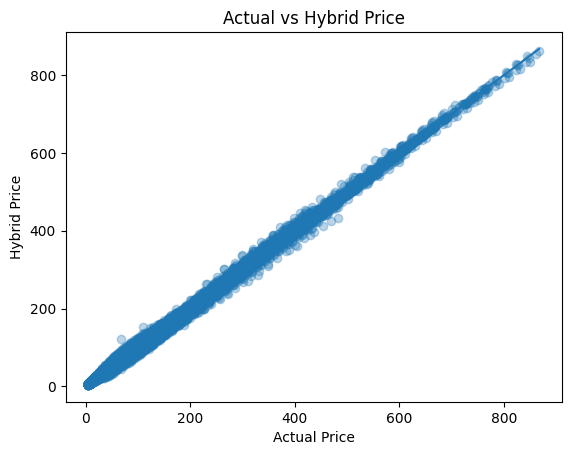

In [53]:
plt.figure()
plt.scatter(df["Market_Price"], df["hybrid_price"], alpha=0.3)

plt.plot([df["Market_Price"].min(), df["Market_Price"].max()],
         [df["Market_Price"].min(), df["Market_Price"].max()])

plt.xlabel("Actual Price")
plt.ylabel("Hybrid Price")
plt.title("Actual vs Hybrid Price")
plt.show()

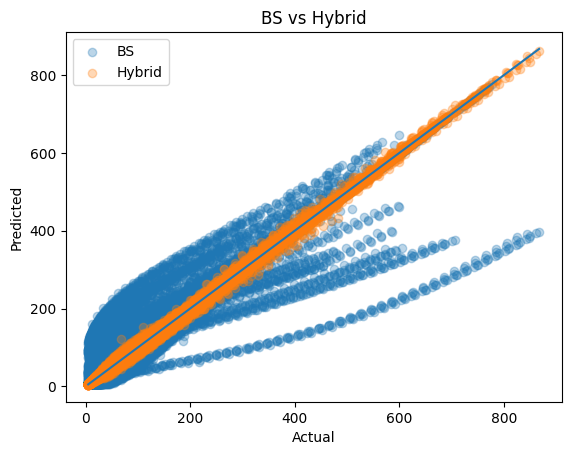

In [54]:
plt.figure()
plt.scatter(df["Market_Price"], df["bs_price"], alpha=0.3, label="BS")
plt.scatter(df["Market_Price"], df["hybrid_price"], alpha=0.3, label="Hybrid")

plt.plot([df["Market_Price"].min(), df["Market_Price"].max()],
         [df["Market_Price"].min(), df["Market_Price"].max()])

plt.legend()
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("BS vs Hybrid")
plt.show()

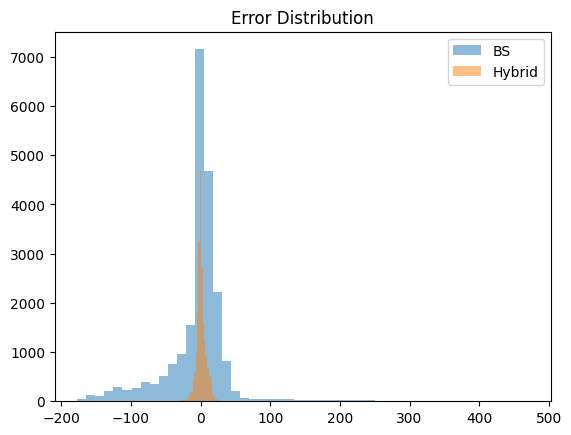

In [38]:
plt.figure()
plt.hist(df["bs_error"], bins=50, alpha=0.5, label="BS")
plt.hist(df["hybrid_error"], bins=50, alpha=0.5, label="Hybrid")

plt.legend()
plt.title("Error Distribution")
plt.show()

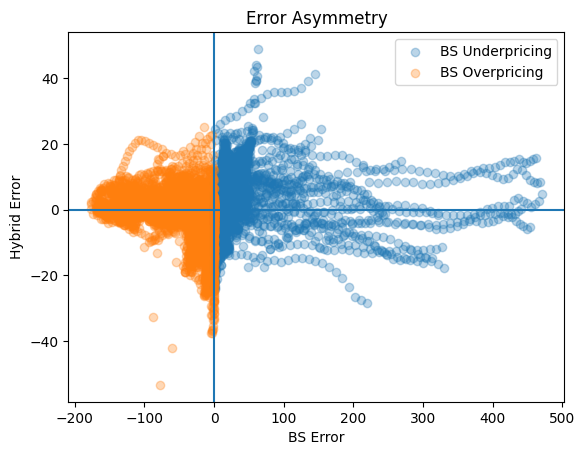

In [55]:
plt.figure()

pos_mask = df["bs_error"] > 0
neg_mask = df["bs_error"] < 0

plt.scatter(df["bs_error"][pos_mask], df["hybrid_error"][pos_mask],
            alpha=0.3, label="BS Underpricing")

plt.scatter(df["bs_error"][neg_mask], df["hybrid_error"][neg_mask],
            alpha=0.3, label="BS Overpricing")

plt.axhline(0)
plt.axvline(0)

plt.xlabel("BS Error")
plt.ylabel("Hybrid Error")
plt.legend()
plt.title("Error Asymmetry")
plt.show()

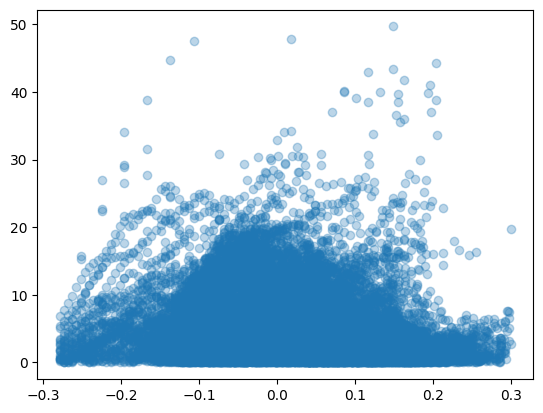

In [40]:
df["abs_error"] = abs(df["hybrid_price"] - df["Market_Price"])

plt.scatter(df["log_moneyness"], df["abs_error"], alpha=0.3)
plt.show()

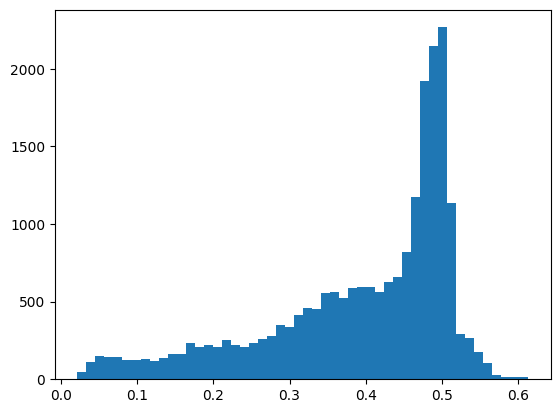

In [41]:
plt.hist(df["alpha"], bins=50)
plt.show()

In [42]:
print(np.mean(np.abs(df["hybrid_error"])) )
print(np.mean(np.abs(df["bs_error"])))

4.765434403386973
27.6438097084828


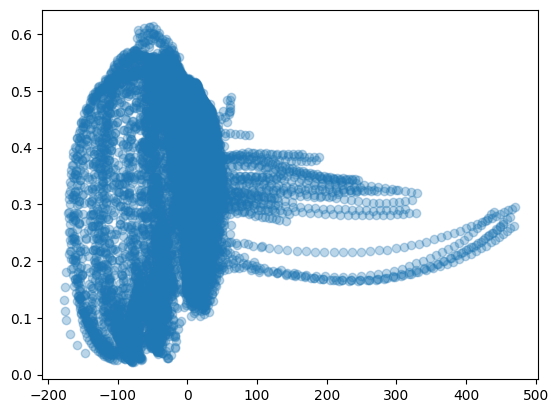

In [43]:
plt.scatter(df["bs_error"], df["alpha"], alpha=0.3)
plt.show()

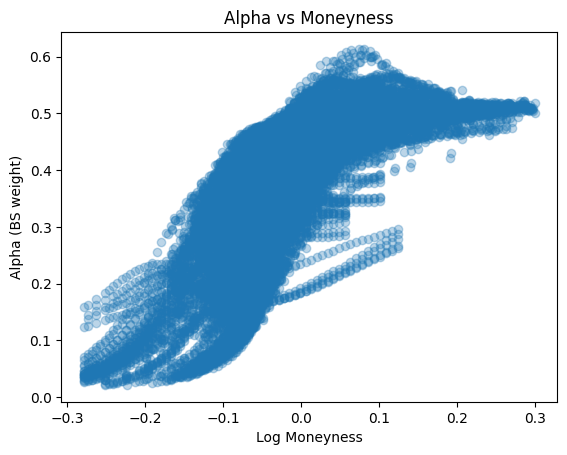

In [44]:
plt.figure()
plt.scatter(df["log_moneyness"], df["alpha"], alpha=0.3)

plt.xlabel("Log Moneyness")
plt.ylabel("Alpha (BS weight)")
plt.title("Alpha vs Moneyness")
plt.show()

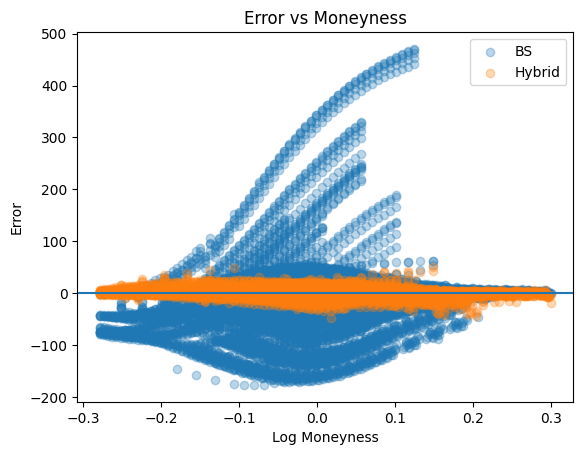

In [45]:
plt.figure()
plt.scatter(df["log_moneyness"], df["bs_error"], alpha=0.3, label="BS")
plt.scatter(df["log_moneyness"], df["hybrid_error"], alpha=0.3, label="Hybrid")

plt.axhline(0)
plt.xlabel("Log Moneyness")
plt.ylabel("Error")
plt.legend()
plt.title("Error vs Moneyness")
plt.show()

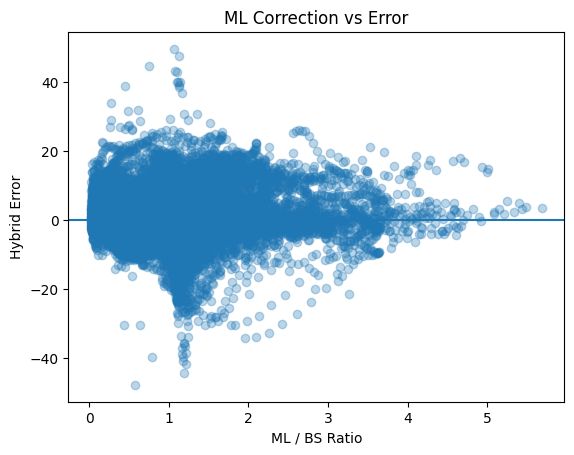

In [46]:
correction = df["ml_price"] / df["bs_price"]

plt.figure()
plt.scatter(correction, df["hybrid_error"], alpha=0.3)

plt.axhline(0)
plt.xlabel("ML / BS Ratio")
plt.ylabel("Hybrid Error")
plt.title("ML Correction vs Error")
plt.show()

In [972]:
# import numpy as np

# model_over=m_over
# model_under=m_under
# alpha_model=alpha_model

# # =============================
# # USER INPUTS
# # =============================
# S=2464.00
# K=2360.00 
# days_to_expiry=11
# r=0.07
# sigma=0.21 
# vix=12.5
# vol_ma=0.20

# # 1. Calculated Features
# T = days_to_expiry / 365.0
# log_moneyness = np.log(S / K)
# sqrt_T = np.sqrt(T)
# sigma_sqrt_T = sigma * sqrt_T

# # 2. Black-Scholes Price (Required as base)
# from scipy.stats import norm
# d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
# d2 = d1 - sigma * np.sqrt(T)
# bs_input_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# # =============================
# # STRUCTURE FOR MODEL
# # =============================
# # Must match the 'features' list exactly
# input_row = pd.DataFrame([[
#     log_moneyness, T, sqrt_T, sigma, sigma_sqrt_T, vix, vol_ma
# ]], columns=features)

# # =============================
# # PREDICTION PIPELINE
# # =============================
# # 1. Predict Regime (Underpriced or Overpriced?)
# regime_val = clf.predict(input_row)[0]

# # 2. Predict ML Log-Error
# if regime_val == 1:
#     log_err_pred = model_under.predict(input_row)[0]
# else:
#     log_err_pred = model_over.predict(input_row)[0]

# # 3. Calculate ML Price
# ml_price_val = bs_input_price * np.exp(log_err_pred)

# # 4. Predict Alpha (The weight between BS and ML)
# alpha_val = np.clip(alpha_model.predict(input_row)[0], 0, 1)

# # 5. Apply Bias Corrections (Mirroring your "Smart Alpha Fix")
# gap_val = (ml_price_val - bs_input_price) / (bs_input_price + eps)

# if gap_val > 0.02:
#     alpha_val = min(alpha_val, 0.2)
# elif gap_val < -0.02:
#     alpha_val = min(alpha_val, 0.5)

# # 6. Final Hybrid Calculation
# final_price = (alpha_val * bs_input_price) + ((1 - alpha_val) * ml_price_val)

# # Safety check: Intrinsic Value
# intrinsic = max(S - K, 0)
# final_price = max(final_price, intrinsic)

# # =============================
# # RESULTS
# # =============================
# print("--- PREDICTION REPORT ---")
# print(f"Black-Scholes Price: {bs_input_price:.2f}")
# print(f"ML Suggested Price:  {ml_price_val:.2f}")
# print(f"Model Alpha:         {alpha_val:.4f}")
# print(f"-------------------------")
# print(f"FINAL HYBRID PRICE:  {final_price:.2f}")